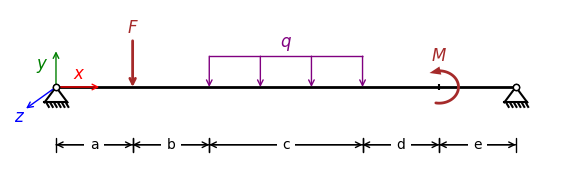

In [3]:
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib import patheffects
import matplotlib.pyplot as plt


def get_max_zorder(ax):
    return max([_.zorder for _ in ax.get_children()])


def add_concentrated_bending_moment(
    ax,
    x, y,
    radius=0.45,
    theta1=-90,
    theta2=90,
    direction="cw",
    color="brown",
    linewidth=2.5,
    head_length=10,
    head_width=8,
    n=80,
    head_arc_deg=10.0,      # <- reserve this many degrees for the arrowhead
    label=None,
    label_offset=(0.0, 0.08),
    tick_size=0.15,
    tick_width=1.5,
):
    t1 = np.deg2rad(theta1)
    t2 = np.deg2rad(theta2)

    # Reserve a small angle for the arrowhead so the tip reaches the arc end visually
    dth = np.deg2rad(head_arc_deg)

    if direction.lower() == "cw":
        # head at theta2, so stop arc early at (theta2 - dth)
        ts_arc = np.linspace(t1, t2 - dth, n)
        th_end = t2
        th_prev = t2 - dth
    elif direction.lower() == "ccw":
        # head at theta1, so start arc late at (theta1 + dth)
        ts_arc = np.linspace(t1 + dth, t2, n)
        th_end = t1
        th_prev = t1 + dth
    else:
        raise ValueError("direction must be 'cw' or 'ccw'")

    # Arc polyline (no head)
    xs = x + radius * np.cos(ts_arc)
    ys = y + radius * np.sin(ts_arc)
    ax.plot(xs, ys, color=color, linewidth=linewidth, solid_capstyle="round", zorder=5)

    # Arrowhead: tangent segment over the reserved angle
    end = np.array([x + radius * np.cos(th_end),  y + radius * np.sin(th_end)])
    prev = np.array([x + radius * np.cos(th_prev), y + radius * np.sin(th_prev)])

    head = FancyArrowPatch(
        prev, end,
        arrowstyle=f"-|>,head_length={head_length},head_width={head_width}",
        linewidth=0,
        facecolor=color,
        edgecolor=color,
        shrinkA=0, shrinkB=0,
        zorder=6,
    )
    ax.add_patch(head)
    
    # vertical tick on the beam, at the point of application
    ax.plot(
        [xM, xM],
        [-tick_size/2, tick_size/2],
        color='black',
        linewidth=tick_width,
        solid_capstyle='butt'
    )

    if label:
        ax.text(
            x + label_offset[0],
            y + radius + label_offset[1],
            label,
            ha="center",
            va="bottom",
            color=color,
            fontsize=12
        )

    return head


def add_hinge(ax, x, y, s=20, fc='white', ec='k', lw=1, zorder=None, **kwargs):
    if zorder is None:
        zorder = get_max_zorder(ax) + 1
    ax.scatter(x, y, s=s, fc=fc, ec=ec, lw=lw, alpha=1.0, zorder=zorder, **kwargs)


def add_triangle_support(ax, xy, w, h, hinge_params={}):
    x = [xy[0] - w/2, xy[0] + w/2]
    y = [xy[1] - h, xy[1] -h]
    spec = [patheffects.withTickedStroke(angle=-60, spacing=2.5, length=1.5)]
    ax.plot(x, y, color='k', path_effects=spec)
    x = [xy[0] - w/2, xy[0], xy[0] + w/2]
    y = [xy[1] - h, xy[1], xy[1] -h]
    ax.plot(x, y, color='k')
    add_hinge(ax, xy[0], xy[1], **hinge_params)


fig, ax = plt.subplots(figsize=(7.12, 2))
beam_length = 10.0

# Draw the beam as a thick line
ax.plot([0, beam_length], [0, 0], color='black', linewidth=2, solid_capstyle='butt')

# x axis
ax.annotate(
    "",
    xy=(1, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='r'),
    fontsize=10
)
ax.text(
    0.5,
    0.1,
    r"$x$",
    ha="center",
    va="bottom",
    color="r",
    fontsize=12
)

# y axis
ax.annotate(
    "",
    xy=(0, 1),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='g'),
    fontsize=10
)
ax.text(
    -0.3,
    0.3,
    r"$y$",
    ha="center",
    va="bottom",
    color="g",
    fontsize=12
)

# z axis
ax.annotate(
    "",
    xy=(-0.7, -0.6),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='b'),
    fontsize=10
)
ax.text(
    -0.8,
    -1.0,
    r"$z$",
    ha="center",
    va="bottom",
    color="b",
    fontsize=12
)

# distributed load
distributed_load_height = 0.8
distributed_load_x0 = beam_length / 3
distributed_load_x1 = 2 * beam_length / 3
ax.plot(
    [distributed_load_x0, distributed_load_x1], 
    [distributed_load_height, distributed_load_height], 
    color='purple', 
    linewidth=1, 
    solid_capstyle='butt'
)
for i in range(4):
    ax.annotate(
        "",
        xy=(beam_length/3 + i*(beam_length/3)/3, distributed_load_height),
        xytext=(beam_length/3 + i*(beam_length/3)/3, 0),
        arrowprops=dict(arrowstyle='<-', color='purple', shrinkA=0, shrinkB=0),
        fontsize=10,
    )
ax.text(
    1.5*beam_length/3,
    distributed_load_height + 0.08,
    r"$q$",
    ha="center",
    va="bottom",
    color="purple",
    fontsize=12
)

# concentrated load
xF = beam_length / 6
concentrated_load_height = 1.2
ax.annotate(
    "",
    xy=(xF, concentrated_load_height),
    xytext=(beam_length/6, 0),
    arrowprops=dict(arrowstyle='<-', color='brown', linewidth=2, shrinkA=0, shrinkB=0),
    fontsize=10,
)
ax.text(
    beam_length/6,
    concentrated_load_height + 0.1,
    r"$F$",
    ha="center",
    va="bottom",
    color="brown",
    fontsize=12
)

# I want to add the bending moment here, at 5*beam_length/6
xM = 5 * beam_length / 6
moment_tick_size = 0.15
add_concentrated_bending_moment(
    ax,
    x=xM, y=0.0,           # slightly above beam
    radius=0.42,
    theta1=-100, theta2=120,  # near-semicircle
    direction="cw",         # makes the head appear on the left like your screenshot
    color="brown",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
    label=r"$M$",
    label_offset=(0.0, 0.15),
    tick_size=moment_tick_size
)

add_triangle_support(ax, (0, 0), 0.5, 0.4)
add_hinge(ax, 0, 0)

add_triangle_support(ax, (beam_length, 0), 0.5, 0.4)
add_hinge(ax, beam_length, 0)

# dimension lines
dimension_line_y = -1.5
dimension_segments = [
    (0, xF, "a"),
    (xF, distributed_load_x0, "b"),
    (distributed_load_x0, distributed_load_x1, "c"),
    (distributed_load_x1, xM, "d"),
    (xM, beam_length, "e"),
]
arrows = '<->', '|-|'
for segment in dimension_segments:
    for arr in arrows:
        arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
        if arr == '|-|':
            arrowprops["mutation_scale"] = 5
        ax.annotate(
            "", 
            xy=(segment[0], dimension_line_y), 
            xytext=(segment[1], dimension_line_y), 
            arrowprops=arrowprops
        )
    bbox=dict(fc="white", ec="none")
    ax.text((segment[0] + segment[1]) / 2, dimension_line_y, segment[2], color="black", \
        ha="center", va="center", bbox=bbox, fontsize=10)

# formatting
ax.set_xlim(-1, beam_length + 1)
ax.set_ylim(-2, 2)
ax.axis('off')
plt.show()

# save figure
fig.savefig("../_static/simply_supported_beam_example_1.pdf", format="pdf")
fig.savefig("../_static/simply_supported_beam_example_1_light.png", format="png")

In [ ]:
from PIL import Image
import numpy as np

# Load image
img = Image.open("../_static/simply_supported_beam_example_1_light.png").convert("RGB")
arr = np.array(img)

# PyData dark background color
bg_color = np.array([32, 32, 32], dtype=np.uint8)

# Threshold for detecting "white" background
white_thresh = 245

# Mask: background pixels (nearly white)
bg_mask = np.all(arr >= white_thresh, axis=2)

# Invert the whole image
inv = 255 - arr

# Replace background explicitly
inv[bg_mask] = bg_color

# Save result
Image.fromarray(inv).save("../_static/simply_supported_beam_example_1_dark.png")